In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
import xgboost as xgb

# 读数据
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# 基本信息
print(df.info())

# 缺失值
print('\n--- 缺失值 ---')
print(df.isnull().sum())

# 目标变量：流失率
print('\n--- Churn 分布 ---')
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True))

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [3]:
data = df.copy()

# TotalCharges 列有些是空格字符串，转成数字
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

# 删掉 TotalCharges 为空的行（只有11行）
data = data.dropna(subset=['TotalCharges'])

# 删掉 customerID（对预测没用）
data = data.drop('customerID', axis=1)

# Churn 的 Yes/No 转成 1/0
data['Churn'] = data['Churn'].map({'Yes': 1, 'No': 0})

print('清洗后形状:', data.shape)
print('Churn 分布:')
print(data['Churn'].value_counts())

清洗后形状: (7032, 20)
Churn 分布:
Churn
0    5163
1    1869
Name: count, dtype: int64


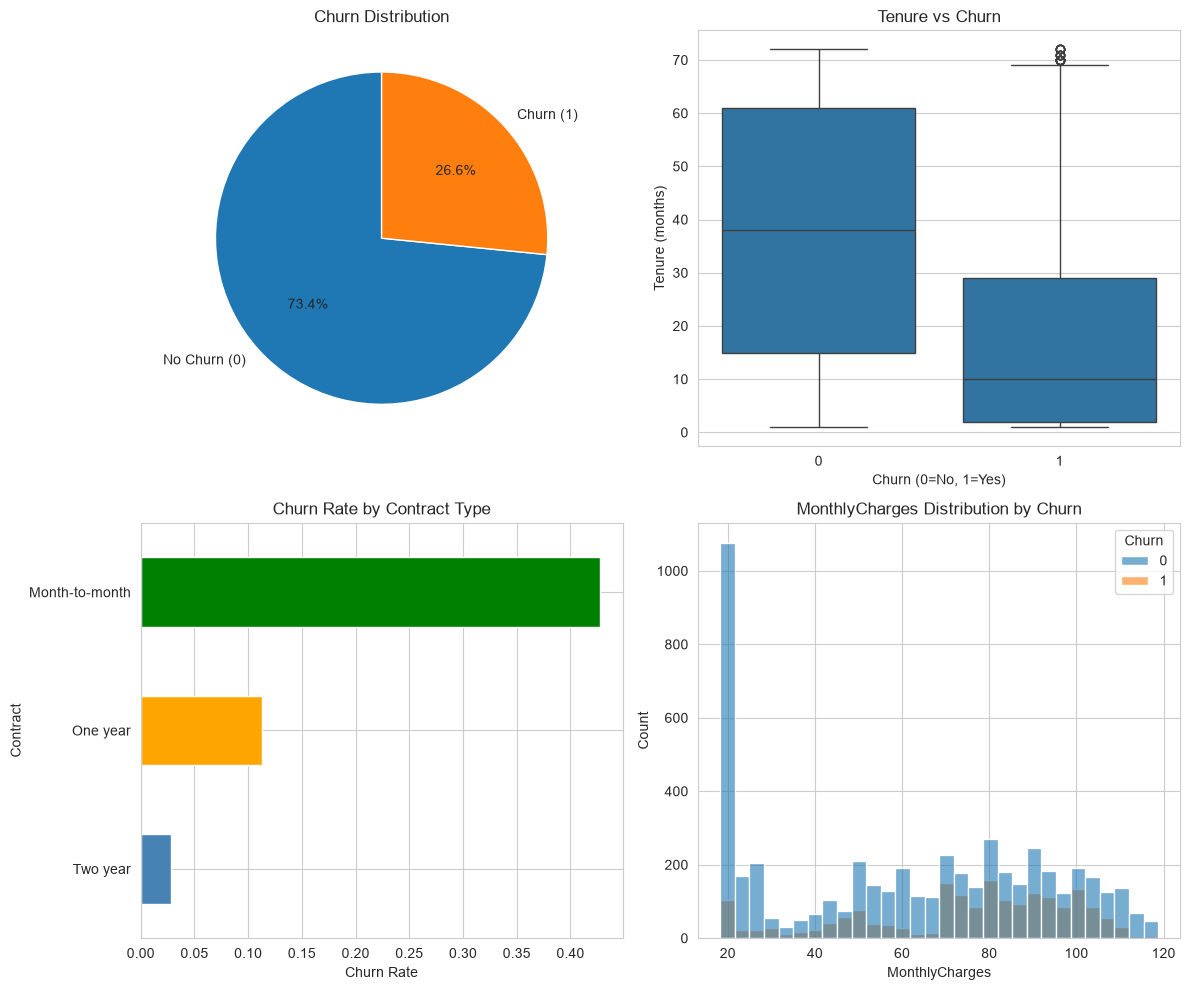

In [4]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 10)

# 图1：Churn 占比饼图
plt.subplot(2, 2, 1)
data['Churn'].value_counts().plot(kind='pie', autopct='%1.1f%%', 
                                   labels=['No Churn (0)', 'Churn (1)'], startangle=90)
plt.title('Churn Distribution')

# 图2：Tenure vs Churn
plt.subplot(2, 2, 2)
sns.boxplot(x='Churn', y='tenure', data=data)
plt.title('Tenure vs Churn')
plt.xlabel('Churn (0=No, 1=Yes)')
plt.ylabel('Tenure (months)')

# 图3：Contract type vs Churn rate
plt.subplot(2, 2, 3)
contract_churn = data.groupby('Contract')['Churn'].mean().sort_values()
contract_churn.plot(kind='barh', color=['steelblue', 'orange', 'green'])
plt.title('Churn Rate by Contract Type')
plt.xlabel('Churn Rate')

# 图4：MonthlyCharges by Churn
plt.subplot(2, 2, 4)
sns.histplot(data=data, x='MonthlyCharges', hue='Churn', bins=30, alpha=0.6)
plt.title('MonthlyCharges Distribution by Churn')

plt.tight_layout()
plt.show()

In [5]:
# 特征和标签
X = data.drop('Churn', axis=1)
y = data['Churn']

# 训练集/测试集 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 数值列和类别列
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [col for col in X.columns if col not in numeric_features]

print(f'数值列: {numeric_features}')
print(f'类别列: {categorical_features}')

数值列: ['tenure', 'MonthlyCharges', 'TotalCharges']
类别列: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ]
)

In [8]:
# 1. Logistic Regression
pipe_lr = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)
y_prob_lr = pipe_lr.predict_proba(X_test)[:, 1]

# 2. Random Forest
pipe_rf = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42))
])
pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)
y_prob_rf = pipe_rf.predict_proba(X_test)[:, 1]

# 3. XGBoost
pipe_xgb = Pipeline([
    ('prep', preprocessor),
    ('model', xgb.XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        scale_pos_weight=(y_train==0).sum() / (y_train==1).sum(),
        random_state=42,
        eval_metric='logloss'
    ))
])
pipe_xgb.fit(X_train, y_train)
y_pred_xgb = pipe_xgb.predict(X_test)
y_prob_xgb = pipe_xgb.predict_proba(X_test)[:, 1]

print('三个模型训练完成')

三个模型训练完成


In [9]:
def evaluate(name, y_true, y_pred, y_prob):
    print(f'{name}:')
    print(f'  Accuracy:  {accuracy_score(y_true, y_pred):.3f}')
    print(f'  Precision: {precision_score(y_true, y_pred):.3f}')
    print(f'  Recall:    {recall_score(y_true, y_pred):.3f}')
    print(f'  F1:        {f1_score(y_true, y_pred):.3f}')
    print(f'  AUC:       {roc_auc_score(y_true, y_prob):.3f}')
    print()

evaluate('Logistic Regression', y_test, y_pred_lr, y_prob_lr)
evaluate('Random Forest', y_test, y_pred_rf, y_prob_rf)
evaluate('XGBoost', y_test, y_pred_xgb, y_prob_xgb)

Logistic Regression:
  Accuracy:  0.726
  Precision: 0.490
  Recall:    0.794
  F1:        0.606
  AUC:       0.835

Random Forest:
  Accuracy:  0.765
  Precision: 0.549
  Recall:    0.639
  F1:        0.591
  AUC:       0.818

XGBoost:
  Accuracy:  0.742
  Precision: 0.510
  Recall:    0.781
  F1:        0.617
  AUC:       0.833



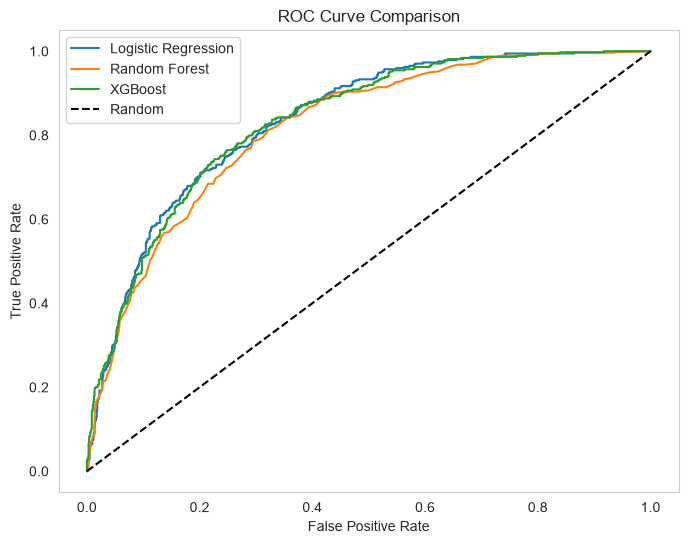

In [10]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label='Logistic Regression')
plt.plot(fpr_rf, tpr_rf, label='Random Forest')
plt.plot(fpr_xgb, tpr_xgb, label='XGBoost')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid()
plt.show()

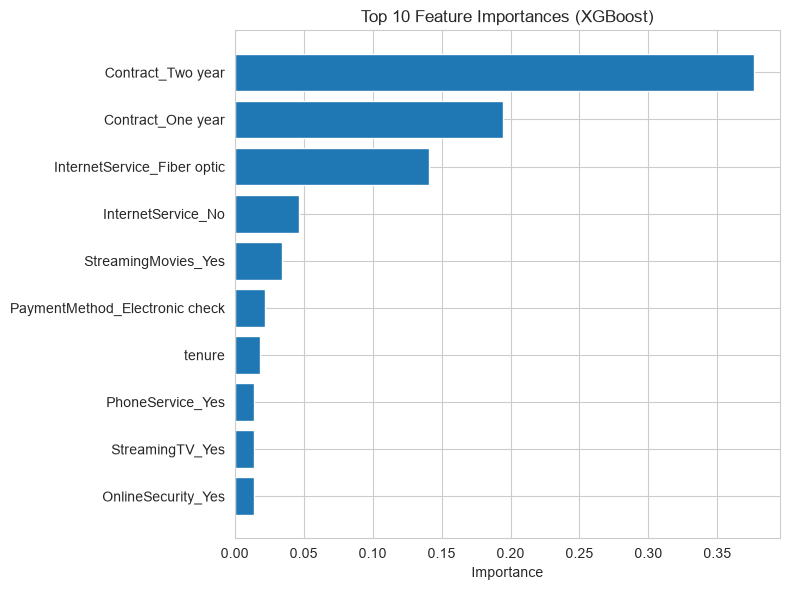

In [11]:
# 获取特征名
cat_features_out = pipe_xgb.named_steps['prep'].named_transformers_['cat'].get_feature_names_out(categorical_features)
feature_names = numeric_features + list(cat_features_out)

# 重要性
importances = pipe_xgb.named_steps['model'].feature_importances_

# 排序取前10
idx = np.argsort(importances)[-10:]

plt.figure(figsize=(8, 6))
plt.barh([feature_names[i] for i in idx], importances[idx])
plt.title('Top 10 Feature Importances (XGBoost)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [12]:
import os
print(os.getcwd())  # 输出当前文件所在的具体文件夹路径


C:\Users\hy001\telco-churn
